Name=Shreeja Shrestha


Sample Code for verifying Directory Structure .

In [134]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of FruitinAmazon.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [136]:
import os
os.listdir("/content/data")

['FruitinAmazon']

In [137]:
import os
# Define dataset path
train_dir = "/content/data/FruitinAmazon/train"
test_dir="/content/data/FruitinAmazon/test"
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [138]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
if os.path.isdir(class_path): # Ensure it’s a valid directory
  images = os.listdir(class_path)
for img_name in images:
  img_path = os.path.join(class_path, img_name)
try:
  with Image.open(img_path) as img:
    img.verify() # Verify image integrity
except (IOError, UnidentifiedImageError):
  corrupted_images.append(img_path)

# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
for img in corrupted_images:
  print(img)
else:
  print("\nNo corrupted images found.")


No corrupted images found.


Sample COde to check the imabalance

In [139]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
  class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


Sample Code for Random Image Selection.

In [140]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

Sample Code for Random Image Plot.

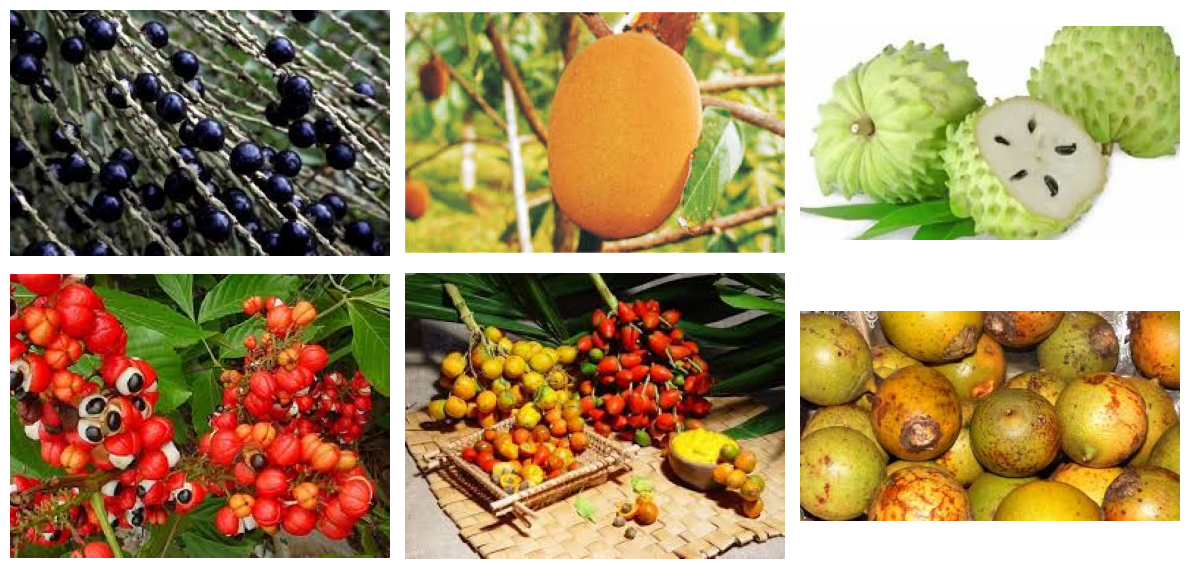

In [141]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    # ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

In [142]:
import os
import zipfile

from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of devnagari digit.zip"

# Where to extract
extract_path = "/content/devnagari_data"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

train_dir = os.path.join(extract_path, "train")

test_dir = os.path.join(extract_path, "test")

if not os.path.exists(train_dir):
    print(" Train directory not found! Check folder structure.")
    print("Available folders:", os.listdir(extract_path))
else:
    class_names = sorted(os.listdir(train_dir))

    if not class_names:
        print(" No class folders found inside train!")
    else:
        print(f" Found {len(class_names)} classes:")
        print(class_names)

print("\n Root folder contents:", os.listdir(extract_path))
if os.path.exists(train_dir):
    print(" Train folder contents:", os.listdir(train_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP extracted successfully!
 Train directory not found! Check folder structure.
Available folders: ['DevanagariHandwrittenDigitDataset']

 Root folder contents: ['DevanagariHandwrittenDigitDataset']


Generating the Train and Val Dataset.

In [143]:
import os

print(os.listdir("/content/devnagari_data"))

['DevanagariHandwrittenDigitDataset']


In [144]:
import os

print(os.listdir("/content/devnagari_data"))

['DevanagariHandwrittenDigitDataset']


In [145]:
train_dir = "/content/devnagari_data/DevanagariHandwrittenDigitDataset/Train"

In [146]:
test_dir = "/content/devnagari_data/DevanagariHandwrittenDigitDataset/Test"

Visualizing training dataset

In [147]:
import tensorflow as tf

image_size = (28, 28)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Found 17000 files belonging to 10 classes.
Using 3400 files for validation.


In [148]:
for images, labels in train_ds.take(1): # Take one batch
  print("Images shape:", images.shape)
  print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


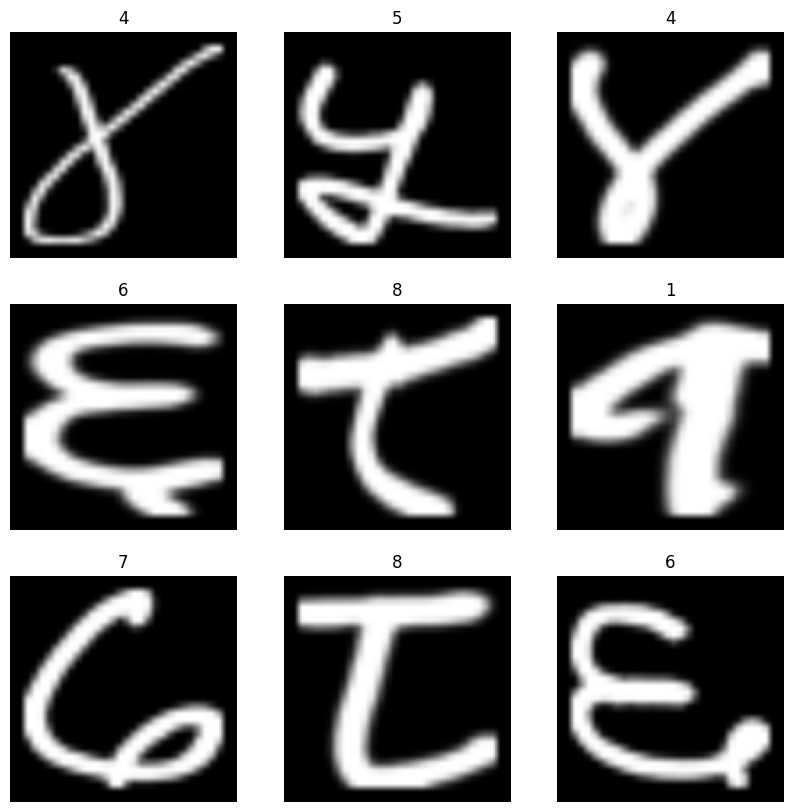

In [149]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):  # correct comment
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Data augmentation with Keras


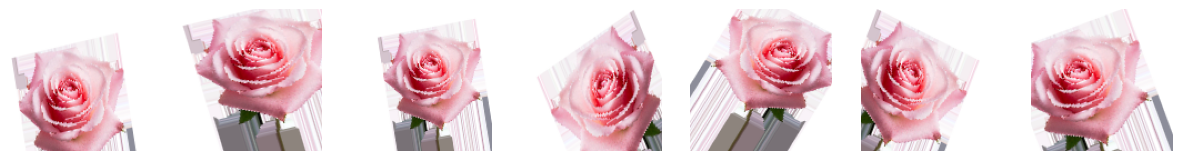

In [150]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# Data augmentation configuration
datagen = ImageDataGenerator(
    rotation_range=30,          # rotate images up to 30 degrees
    width_shift_range=0.2,      # shift width by 20%
    height_shift_range=0.2,     # shift height by 20%
    shear_range=0.2,            # shear transformation
    zoom_range=0.2,             # zoom in/out
    horizontal_flip=True,       # flip images horizontally
    fill_mode='nearest'         # fill missing pixels
)

# Load image
img = load_img('/content/drive/MyDrive/AI and Machine Learning/rosee (1).png', target_size=(128, 128))


x = img_to_array(img)


x = np.expand_dims(x, axis=0)
# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)

# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))

for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')

plt.show()

Define Augmentation Layers

In [151]:
import tensorflow as tf
from tensorflow.keras import layers

# Define augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),          # Extra augmentation
    layers.RandomContrast(0.1)       # Extra augmentation
]

Create Augmentation Function

In [152]:
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

Add Augmentation Inside Model

In [153]:
from tensorflow import keras

model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Apply augmentation here
    *data_augmentation_layers,

    # CNN layers
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

Visualizzze Augmented Images

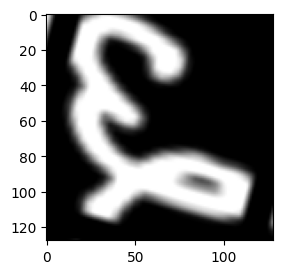

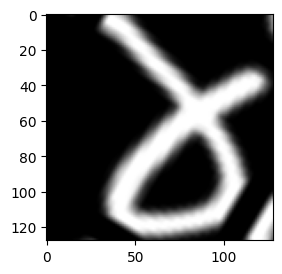

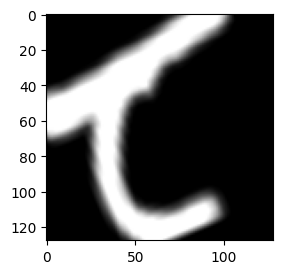

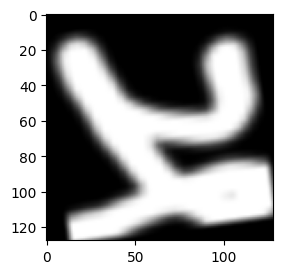

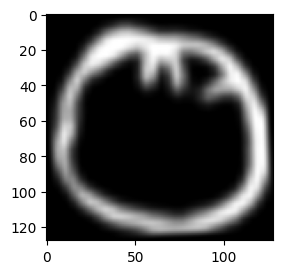

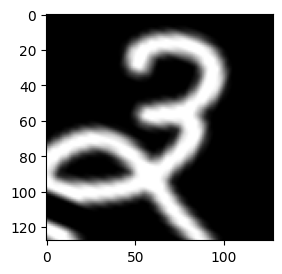

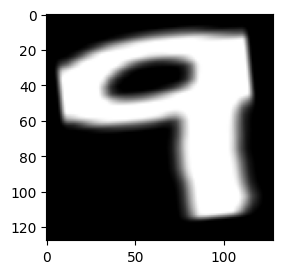

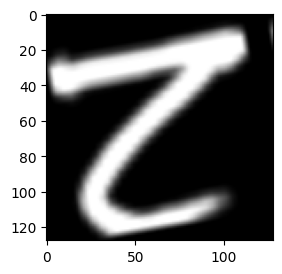

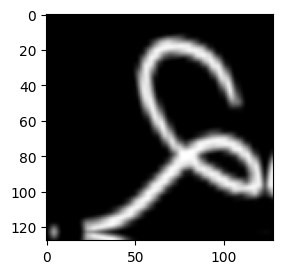

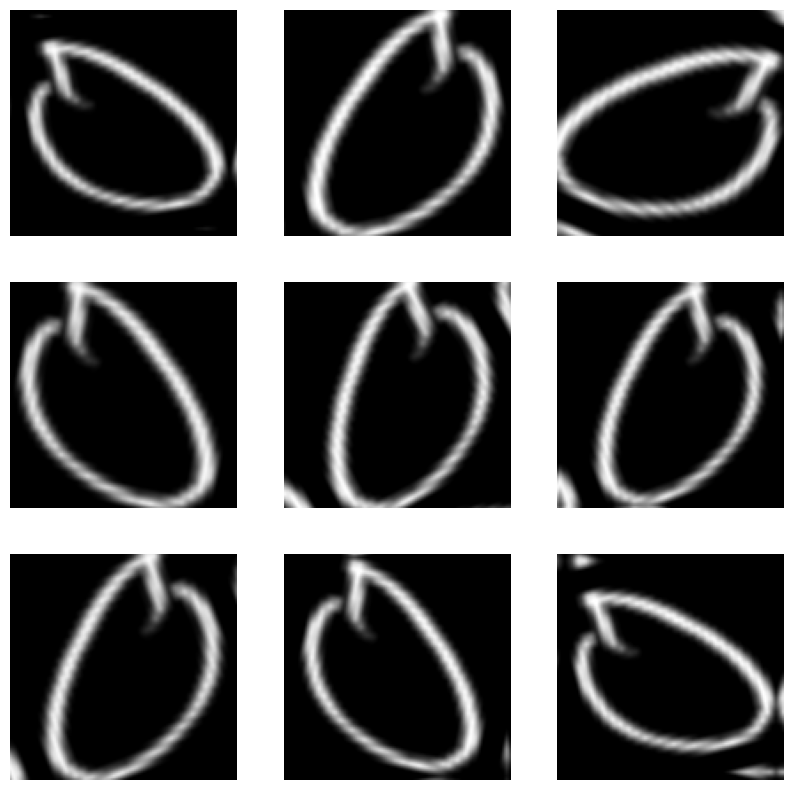

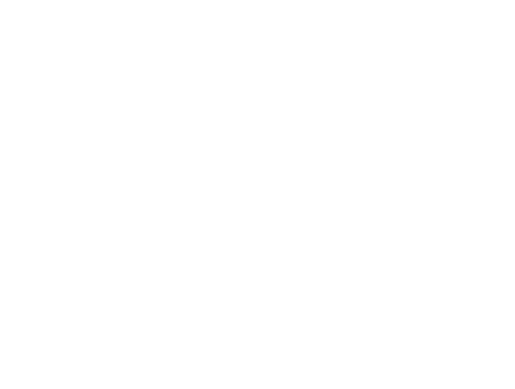

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(images)[0]
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")

plt.show()
plt.axis("off")

plt.show()

Model Buid

In [155]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation

# Data augmentation
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Model
model = Sequential([

    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    # 1st Conv Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 2nd Conv Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 3rd Conv Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 4th Conv Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Dense Layers
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output
    Dense(6, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

Task 1 – Improved CNN Model (with Augmentation, BN, Dropout)

In [156]:
train_dir = "/content/data/FruitinAmazon/train"
test_dir="/content/data/FruitinAmazon/test"


In [157]:
import os

train_dir = "/content/data/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

print("Classes:", class_names)
print("Total classes:", len(class_names))

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total classes: 6


In [158]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Data Augmentation

In [159]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
]

Optimize Dataset

In [160]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [162]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

Improved Deep CNN Model

In [163]:
from tensorflow.keras import models

model = models.Sequential([

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

Compile MOdel

In [164]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRain Model

In [165]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2917 - loss: 2.4435 - val_accuracy: 0.2222 - val_loss: 1.8027
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5278 - loss: 1.2346 - val_accuracy: 0.1111 - val_loss: 1.9328
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7361 - loss: 0.7252 - val_accuracy: 0.1111 - val_loss: 2.3471
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7361 - loss: 0.7629 - val_accuracy: 0.0556 - val_loss: 2.9283
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7500 - loss: 0.6782 - val_accuracy: 0.0556 - val_loss: 3.4847
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7500 - loss: 0.6618 - val_accuracy: 0.1667 - val_loss: 4.2235
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.8056 - loss: 0.6473 - val_accuracy: 0.1667 - val_loss: 5.2521
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8333 - loss: 0.5799 - val_accuracy: 0.2222 - val_loss: 6.5351
Epoch 9/15
3/3

Transfer Learning(VGG16 for fruits)

Load VGG16

In [166]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

Freeze Layers

In [167]:
for layer in base_model.layers:
    layer.trainable = False

Add Cusom classifer

In [168]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

Compile VGG16model

In [169]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Train VGG16 model



In [170]:
history_vgg = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 8s/step - accuracy: 0.1389 - loss: 16.0926 - val_accuracy: 0.1111 - val_loss: 8.8550
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.1667 - loss: 14.7343 - val_accuracy: 0.1111 - val_loss: 8.1844
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 8s/step - accuracy: 0.2222 - loss: 11.3640 - val_accuracy: 0.1667 - val_loss: 7.7123
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.2639 - loss: 10.3376 - val_accuracy: 0.1111 - val_loss: 7.1500
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.1944 - loss: 11.5632 - val_accuracy: 0.1111 - val_loss: 6.7223
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.2778 - loss: 9.1258 - val_accuracy: 0.1111 - val_loss: 6.4097
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.2917 - loss: 6.7044 - val_accuracy: 0.1111 - val_loss: 6.2362
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 8s/step - accuracy: 0.3056 - loss: 6.9319 - val_accuracy: 0.1111 - val_loss: 5.9616
Epo

In [172]:
model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Visualization Graph

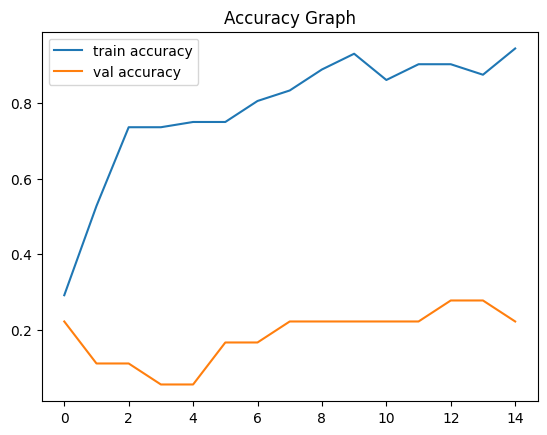

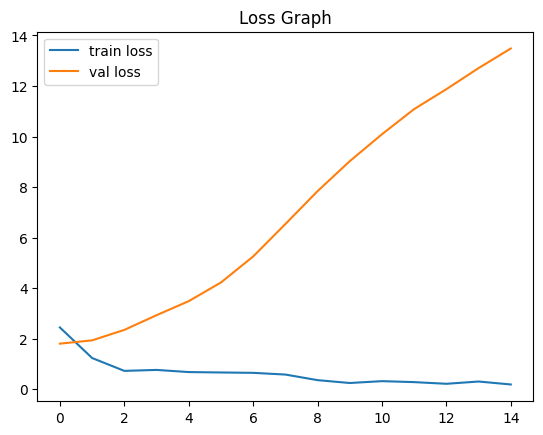

In [173]:


# Accuracy graph
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

prediction

In [176]:
import tensorflow as tf
import numpy as np

for images, labels in val_ds.take(1):
    images = tf.image.resize(images, (224, 224))

    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    print("Predicted:", pred_labels[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
Predicted: [4 5 5 5 5]


Task2

Trained Model (VGG16)

Dataset

In [183]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Preprocessing

In [184]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [185]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

num_classes = 6

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [186]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 18s/step - accuracy: 0.2917 - loss: 6.3305 - val_accuracy: 0.3889 - val_loss: 2.8027
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.7500 - loss: 1.0453 - val_accuracy: 0.5556 - val_loss: 1.3047
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.8889 - loss: 0.2756 - val_accuracy: 0.6667 - val_loss: 1.0567
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.9583 - loss: 0.0943 - val_accuracy: 0.6111 - val_loss: 1.1690
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.6111 - val_loss: 1.3341


Evaluate

In [187]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6111 - loss: 1.3341
Validation Accuracy: 0.6111111044883728


Inference Output

In [188]:
import numpy as np

predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

y_true = []
for _, y in val_ds:
    y_true.extend(y.numpy())

y_true = np.array(y_true)

print("Predicted:", y_pred[:10])
print("Actual:   ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
Predicted: [0 4 2 5 4 5 0 3 4 4]
Actual:    [3 4 4 4 2 4 3 2 5 2]


Classification Report

In [182]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         3

    accuracy                           0.06        18
   macro avg       0.08      0.08      0.08        18
weighted avg       0.06      0.06      0.06        18

